# 07 · Chang–Cooper 3D (x, z, φ): FP, deterministic, and SDE

Full 3D setup from the original Chang–Cooper notebook: advection in x and z, drift–diffusion in φ, periodic in φ. We compare three views:
- FP PDE (Chang–Cooper on φ, upwind on x/z)
- Deterministic drift-only trajectories (σ→0)
- SDE paths with diffusion in φ and histogram vs FP

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from stochlib.setup import Grid, InitialCondition, VelocitiesConfig, DiffusionConfig
from stochlib.boundary_conditions import BoundaryConditions
from stochlib.fokker_planck import SimulationEngine, StabilityAnalyzer
from stochlib.fokker_planck.plotting.distributions import plot_1d_distribution, plot_1d_overlay
from stochlib.sde.bridge import fp_to_sde_drift, fp_to_sde_diffusion, grid_bounds_from_grid
from stochlib.sde.solver import PathSimulator

plt.rcParams["figure.figsize"] = (12, 4)
np.set_printoptions(precision=3, suppress=True)

In [26]:
# Parameters from the original 3D Chang–Cooper notebook
sigma = 0.001
beta = 100.0
lamda = 0.6
alpha = 0.1
v0 = 0.01
vg = 0.0
psi = 1e9  # effectively infinite (removes 1/(2ψ) term)
D0 = 1e-5  # diffusion in φ only

# Domain and resolution (kept moderate for runtime)
x_min, x_max, Nx = 0.0, 50.0, 80
z_min, z_max, Nz = -3.0, 1.0, 40
phi_min, phi_max, Nphi = -np.pi, np.pi, 96

t_final = 200
dt_guess = 5e-3

# Initial Gaussian center/widths
x0, z0, phi0 = 5.0, -1.0, -0.5 * np.pi
sigma_x, sigma_z, sigma_phi = 1.0, 0.4, 0.5

In [27]:
def mu_x_field(X, Z, PHI, t=0.0):
    return alpha * np.exp(Z) * np.cos(X - t) + v0 * np.sin(PHI) + sigma * (beta + Z)


def mu_z_field(X, Z, PHI, t=0.0):
    return alpha * np.exp(Z) * np.sin(X - t) + v0 * np.cos(PHI) - vg


def mu_phi_field(X, Z, PHI, t=0.0):
    return (
        lamda * alpha * np.exp(Z) * np.cos(X - t + 2.0 * PHI)
        - (1.0 / (2.0 * psi)) * np.sin(PHI)
        + 0.5 * sigma * (1.0 + lamda * np.cos(2.0 * PHI))
    )


def diffusion_phi_field(X, Z, PHI, t=0.0):
    return np.full_like(PHI, D0)

In [28]:
# 3D grid: x, z, phi (mapped to x, y, z axes respectively)
grid = Grid(
    x_start=x_min,
    x_end=x_max,
    num_points_x=Nx,
    y_start=z_min,
    y_end=z_max,
    num_points_y=Nz,
    z_start=phi_min,
    z_end=phi_max,
    num_points_z=Nphi,
)

# Boundary conditions: open in x and z, periodic in phi
bc = BoundaryConditions(grid, bc_x="open", bc_y="open", bc_z="periodic")

# Initial condition: 3D Gaussian bump
ic = InitialCondition(
    grid,
    func_type="gaussian",
    x0=x0,
    y0=z0,
    z0=phi0,
    sigma_x=sigma_x,
    sigma_y=sigma_z,
    sigma_z=sigma_phi,
)

# Physics configs
velocities = VelocitiesConfig(grid, mu_x=mu_x_field, mu_y=mu_z_field, mu_z=mu_phi_field)
diffusions = DiffusionConfig(grid, axes=["x", "y", "z"], constants={"x": 0.0, "y": 0.0, "z": D0})

# Stability analysis
diag = StabilityAnalyzer.analyze(grid, velocities, diffusions, dt_user=dt_guess, t=0.0)
dt = 0.8 * diag.dt_max
t_array = np.arange(0.0, t_final + dt, dt)
print(f"Max stable dt ≈ {diag.dt_max:.3e}; using dt = {dt:.3e}; steps = {len(t_array)}")
print(f"Grid shape: {grid.shape}, volume element dV={grid.volume_element:.3e}")

Max stable dt ≈ 9.871e-02; using dt = 7.897e-02; steps = 2534
Grid shape: (80, 40, 96), volume element dV=4.293e-03


In [29]:
# Fokker–Planck simulation (Chang–Cooper on φ, upwind elsewhere is automatic)
engine = SimulationEngine(grid, velocities, diffusions, bc)
fp_result = engine.run(
    f0=ic.f0,
    t_array=t_array,
    save_interval=max(1, len(t_array) // 10),
    report_interval=0,
    confirm_run=False,
)
fp_final = fp_result["final"]


               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x, y, z
  Total grid points    : 307,200
  Grid deltas (Δ)      : {'x': np.float64(0.6329113924050633), 'y': np.float64(0.10256410256410264), 'z': np.float64(0.06613879270715373)}
  Volume element (dV)  : 4.293e-03

BOUNDARY CONDITIONS:
  x      : open
  y      : open
  z      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 3.828e-01
  Max diffusion (D)    : 1.000e-05

TIME STEPPING:
  dt (requested)       : 7.897e-02
  dt_max (CFL stable)  : 9.871e-02
  Total steps          : 2533
  Time window          : [t=0.000e+00, t=2.000e+02]

NUMERICAL SCHEMES:
  x      : upwind_cn
  y      : upwind_cn
  z      : upwind_cn

DIAGNOSTICS:
  Report interval      : every 0 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0025 GB
  Num fields           : 7 (f + velocities + diffusion)
  Est. total memory    : 0.0172 GB
  Est. runtime         : 62.2510 s (rough;

In [30]:
# Deterministic trajectories (σ→0) using PathSimulator with diffusion=0


def drift_only(x, t):
    return np.column_stack(
        [
            mu_x_field(x[:, 0], x[:, 1], x[:, 2], t),
            mu_z_field(x[:, 0], x[:, 1], x[:, 2], t),
            mu_phi_field(x[:, 0], x[:, 1], x[:, 2], t),
        ]
    )


zero_diffusion = lambda x, t: np.zeros_like(x)

det_sim = PathSimulator(drift_only, zero_diffusion, scheme="euler_maruyama")
n_paths_det = 500
det_paths_res = det_sim.simulate(
    x0=np.array([x0, z0, phi0]),
    n_paths=n_paths_det,
    t_array=t_array,
    save_paths=True,
)
det_paths = det_paths_res["paths"]
# Wrap phi to [-π, π]
det_paths[:, :, 2] = ((det_paths[:, :, 2] + np.pi) % (2 * np.pi)) - np.pi
det_phi_final = det_paths[:, -1, 2]

In [31]:
# SDE paths (with diffusion in φ)
sde_drift = fp_to_sde_drift(velocities, grid)
sde_diffusion = fp_to_sde_diffusion(diffusions, grid)
bounds = grid_bounds_from_grid(grid)
sde_sim = PathSimulator(
    sde_drift, sde_diffusion, scheme="auto", bounds=bounds, boundary_mode="reflect"
)
n_paths = 2000
paths_res = sde_sim.simulate(
    x0=np.array([x0, z0, phi0]), n_paths=n_paths, t_array=t_array, save_paths=True
)
paths = paths_res["paths"]
paths[:, :, 2] = ((paths[:, :, 2] + np.pi) % (2 * np.pi)) - np.pi
phi_final = paths[:, -1, 2]

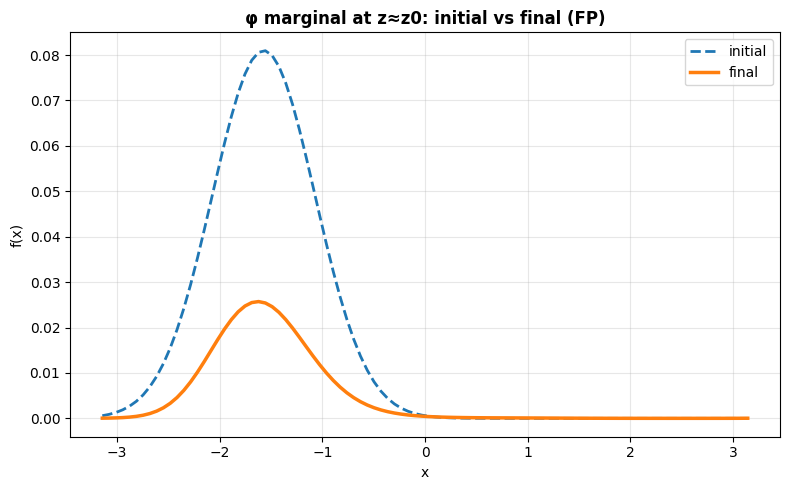

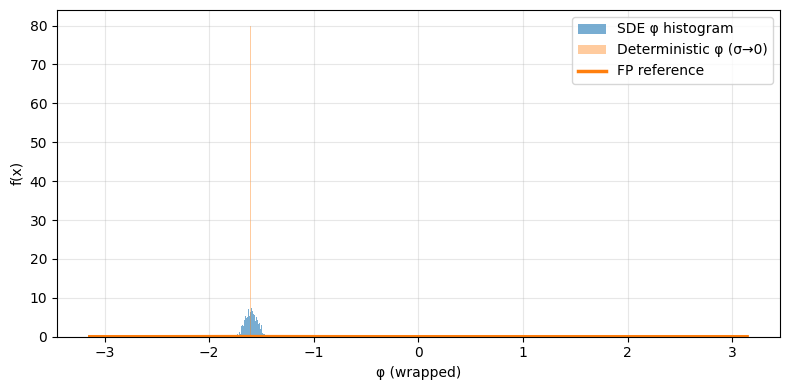

In [32]:
# Visual comparison at final time using built-in plotting helpers
phi_grid_obj = Grid(x_start=phi_min, x_end=phi_max, num_points_x=Nphi)

# φ-marginals at z ≈ z0
z_idx = np.argmin(np.abs(grid.y_grid - z0))
ic_phi = ic.f0[:, z_idx, :].sum(axis=0) * grid.dx * grid.dy
fp_phi = fp_final[:, z_idx, :].sum(axis=0) * grid.dx * grid.dy

# Overlay initial vs final φ distribution (FP)
fig_overlay = plot_1d_overlay(
    phi_grid_obj,
    ic_phi,
    fp_phi,
    title="φ marginal at z≈z0: initial vs final (FP)",
)

# SDE/Deterministic histogram vs FP reference
fig_hist, ax = plt.subplots(figsize=(8, 4))
ax.hist(phi_final, bins=80, density=True, alpha=0.6, label="SDE φ histogram")
ax.hist(det_phi_final, bins=80, density=True, alpha=0.4, label="Deterministic φ (σ→0)")
plot_1d_distribution(phi_grid_obj, fp_phi, ax=ax, color="C1", linewidth=2.5, label="FP reference")
ax.set_xlabel("φ (wrapped)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()